# IBL Brain-Wide Map Project

Analysis notebook built on the International Brain Laboratory (IBL) Brain-Wide Map dataset.

The dataset contains whole-mouse-brain Neuropixels recordings during a standardized visual decision-making task. This notebook sets up the connection to the public IBL data server, downloads precomputed PSTHs, and defines utility functions for loading and analyzing neural activity.

## Running this notebook

**Google Colab:** Just run all cells. The setup cell clones this repo (bringing in the committed decode cache and `requirements.txt`) and installs the dependencies for you.

**Locally:** Create an environment and install dependencies first:

```bash
python -m venv .venv
# Windows:  .venv\Scripts\activate
# macOS/Linux:  source .venv/bin/activate
pip install -r requirements.txt
```

Then select the `.venv` as your notebook kernel and run all cells. The setup cell is a no-op locally (you manage your own environment).

## Install dependencies, setup, and import libraries

## Clone the repo and install dependencies (Colab)

In Colab the runtime starts empty, so the next cell `git clone`s this repo
(read-only, no token), `cd`s into it, and installs from `requirements.txt`.
Cloning does two things:

1. Brings the committed decode cache (`./decode_cache/`) and `requirements.txt`
   into the runtime, so the install and cache-load cells find them.
2. Makes the repo root the working directory, so all `./` paths resolve.

Locally this cell is a no-op — you already have the checkout and manage your own
environment. Regenerating the cache is a separate, explicit `FORCE_RERUN=True` step.


In [1]:
# Colab setup: clone the repo (read-only, no token), cd in, and install deps.
# The clone brings the committed cache (./decode_cache/) and requirements.txt
# into the runtime; cd makes the repo root the working directory so ./ paths resolve.
# Locally this is a no-op — you already have the checkout and manage your own env.
import os
import sys

IN_COLAB = "google.colab" in sys.modules

REPO_URL = "https://github.com/thisisrick25/cn-project.git"
REPO_DIR = "cn-project"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        print(f"Cloning {REPO_URL} ...")
        !git clone --depth 1 {REPO_URL}
    else:
        print(f"{REPO_DIR}/ already present; pulling latest ...")
        !git -C {REPO_DIR} pull --ff-only
    os.chdir(REPO_DIR)
    print(f"Working directory: {os.getcwd()}")
    print("Installing from requirements.txt ...")
    %pip install -q -r requirements.txt
else:
    print("Local run: using the repo checkout on disk.")
    print("Install deps with: pip install -r requirements.txt")


Cloning https://github.com/thisisrick25/cn-project.git ...
Cloning into 'cn-project'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 14 (delta 0), reused 12 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 1.23 MiB | 3.02 MiB/s, done.
Working directory: /content/cn-project
Installing from requirements.txt ...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 124.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.6/442.6 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━

In [2]:
# When running in jupyter set number of threads to 1
from one.api import ONE
os.environ.setdefault('ONE_HTTP_DL_THREADS', '1')

ONE.setup(base_url='https://openalyx.internationalbrainlab.org', silent=True)
one = ONE(password='international')

Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import pandas as pd
from scipy import sparse
import numpy as np
from one.remote.aws import s3_download_file
import zipfile
import tqdm
import scipy.stats as stats
from iblutil.util import Bunch
from scipy.ndimage import gaussian_filter1d

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# This is to view dataframe interactively in Google colab
if 'google.colab' in sys.modules:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()

# This is to style figures (optional — skip gracefully if unavailable)
try:
    from ibl_style.style import figure_style
    figure_style()
except Exception as e:
    print(f"ibl_style not applied ({e}); using default matplotlib style")


## Data Access

### Data Format

This project uses **precomputed PSTHs** (peri-stimulus time histograms) for all *good* clusters in the Brain-Wide Map. The data is provided as three ZIP archives, one per task-event alignment:

| Event | File | Aligned to |
| --- | --- | --- |
| `stimOn` | `data_stimOn.zip` | Stimulus onset |
| `firstMove` | `data_firstMove.zip` | First wheel movement |
| `feedback` | `data_feedback.zip` | Reward / error feedback |

Each archive (~810 MB) contains:

- **`clusters.pqt`** — per-cluster metadata. Key columns: `psth_index` (row into the PSTH array), `uuids` (globally unique cluster id), `cluster_id`, `firing_rate`, `x`/`y`/`z` (CCF coordinates), `atlas_id_allen`, `pid` (probe insertion), `acronym` (Allen CCF brain region), `acronym_allen`.
- **`trials.pqt`** — trial variables: `contrastLeft`, `contrastRight`, `choice`, `probabilityLeft` (block), `feedback`.
- **`sessions.pqt`** — session info mapping `eid` ↔ `pid`, plus `subject`, `lab`.
- **`t.npy`** — PSTH timebase, from −0.5 s to +1.0 s in 10 ms bins (150 bins, `dt = 0.01`).
- **`{pid}.npz`** — one sparse PSTH array per probe insertion, reshaped to `(trials, clusters, nbins)`.

**IDs:** an `eid` identifies an *experimental session*; a `pid` identifies a single *probe insertion*. One session (`eid`) can have multiple probe insertions (`pid`s).

### Data loading utilities

The functions below download, unzip, and load the data into memory. `download_data(event)` fetches and extracts an archive; `load_metadata(event)` reads the metadata tables and PSTH timebase into a `Bunch`; `load_psth(...)` loads a probe insertion's sparse PSTH; and the `get_*_psth_*` helpers aggregate PSTHs by probe insertion, brain region, or specific clusters (optionally split by a task variable).

In [4]:
def download_data(event):
  assert event in ['firstMove', 'stimOn', 'feedback'], 'event must be one of "firstMove", "stimOn" or "feedback'

  # Dataset name
  fname = f'data_{event}.zip'
  # Remote location of data
  s3_data_path = f'sample_data/Neuromatch/{fname}'
  # Local location to download data to
  save_path = one.cache_dir.joinpath('Neuromatch', fname)
  save_path.parent.mkdir(exist_ok=True, parents=True)

  # Download file
  file = s3_download_file(s3_data_path, save_path)
  # Unzip content
  with zipfile.ZipFile(file, 'r') as zip_ref:
    zip_ref.extractall(save_path.parent)


def get_data_path(event):

  return one.cache_dir.joinpath('Neuromatch', f'data_{event}')

In [5]:
def load_metadata(event):
  metadata = Bunch()
  data_path = get_data_path(event)
  metadata['clusters'] = pd.read_parquet(data_path.joinpath('clusters.pqt'))
  metadata['trials'] = pd.read_parquet(data_path.joinpath('trials.pqt'))
  metadata['sessions'] = pd.read_parquet(data_path.joinpath('sessions.pqt'))
  metadata['times'] = np.load(data_path.joinpath('t.npy'))
  metadata['nbins'] = metadata['times'].size
  metadata['dt'] = np.round(np.median(np.diff(metadata['times'])), 2)
  metadata['data_path'] = data_path

  return metadata


def load_psth(data_path, pid, nbins=150):
    psth = sparse.load_npz(data_path.joinpath(f'{pid}.npz')).toarray()
    psth = psth.reshape(psth.shape[0], -1, nbins)
    return psth

In [6]:
def split_trials_by_variable(trials, split='contrast'):
  trials = trials.set_index('psth_index')
  if split == 'contrast':
    trials['contrast'] = np.nansum([trials['contrastLeft'], trials['contrastRight']], axis=0) * 100
    grp = trials.groupby('contrast')
  elif split == 'signed contrast':
    trials['signedContrast'] = np.nansum([-1 * trials['contrastLeft'], trials['contrastRight']], axis=0) * 100
    grp = trials.groupby('signedContrast')
  elif split == 'stimulus':
    trials['stimulus'] = 'right'
    trials.loc[trials['contrastRight'].isna(), 'stimulus'] = 'left'
    grp = trials.groupby('stimulus')
  elif split == 'choice':
    grp = trials.groupby('choice')
  elif split == 'block':
    grp = trials.groupby('probabilityLeft')
  else:
    raise NotImplementedError('split must be one of "contrast", "signed contrast", "stimulus", "choice" or "block"')

  return grp.groups


def get_avg_psth_for_insertion(pid, meta, reg=None, uuids=None, split=None):

  df = meta.clusters[meta.clusters['pid'] == pid]
  df = df[['acronym', 'pid', 'uuids', 'cluster_id', 'psth_index']]
  sp = load_psth(meta.data_path, pid, nbins=meta.nbins)

  if reg is not None:
    in_reg = df['acronym'] == reg
    sp = sp[:, in_reg.values, :]
    df = df[in_reg].reset_index(drop=True)

  if uuids is not None:
    in_uuid = df['uuids'].isin(uuids)
    sp = sp[:, in_uuid.values, :]
    df = df[in_uuid].reset_index(drop=True)

  if split is None:
    psth = sp.mean(axis=0) / meta['dt']
  else:
    psth = dict()
    eid = meta.sessions[meta.sessions['pid'] == pid].iloc[0]['eid']
    trials = meta.trials[meta.trials['eid'] == eid].reset_index(drop=True)
    grps = split_trials_by_variable(trials, split=split)

    for key, vals in grps.items():
      psth[key] = sp[vals, :, :].mean(axis=0)

  return psth, df

def get_avg_psth_for_region(reg, meta, split=None):
  clusters = meta.clusters[meta.clusters['acronym'] == reg]
  pids = clusters['pid'].unique()
  all_df = []
  all_psth = []
  for pid in pids:
    psth, df = get_avg_psth_for_insertion(pid, meta, reg=reg, split=split)
    all_df.append(df)
    all_psth.append(psth)

  all_df = pd.concat(all_df).reset_index(drop=True)
  if split is None:
    all_psth = np.concatenate(all_psth)
  else:
    all_psth = {key: np.concatenate([d[key] for d in all_psth if key in d.keys()])
    for key in all_psth[0]}


  return all_psth, all_df
def get_psth_for_insertion(pid, meta, reg=None, uuids=None):

  df = meta.clusters[meta.clusters['pid'] == pid]
  df = df[['acronym', 'pid', 'uuids', 'cluster_id', 'psth_index']]
  sp = load_psth(meta.data_path, pid, nbins=meta.nbins)

  if reg is not None:
    in_reg = df['acronym'] == reg
    sp = sp[:, in_reg.values, :]
    df = df[in_reg].reset_index(drop=True)

  if uuids is not None:
    in_uuid = df['uuids'].isin(uuids)
    sp = sp[:, in_uuid.values, :]
    df = df[in_uuid].reset_index(drop=True)


  eid = meta.sessions[meta.sessions['pid'] == pid].iloc[0]['eid']
  trials = meta.trials[meta.trials['eid'] == eid].reset_index(drop=True)
  psth = sp / meta['dt']

  return psth, df, trials


def get_psth_for_region(reg, meta):

  clusters = meta.clusters[meta.clusters['acronym'] == reg]
  pids = clusters['pid'].unique()
  all_clust = []
  all_psth = []
  all_trials = []
  for pid in pids:
    psth, clust, trials = get_psth_for_insertion(pid, meta, reg=reg)
    all_clust.append(clust)
    all_psth.append(psth)
    all_trials.append(trials)

  return all_psth, all_clust, all_trials


### Explore the data

Pick an event alignment, download the data, and inspect the metadata tables. Change `event` to `'firstMove'` or `'feedback'` to align to a different task event.

In [7]:
event = 'stimOn'
download_data(event)
meta = load_metadata(event)

print('metadata keys:', list(meta.keys()))
print('n clusters:', len(meta.clusters))
print('n bins:', meta.nbins, '| dt:', meta.dt, 's')
print('time range:', meta.times[0], 'to', meta.times[-1], 's')

(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/Neuromatch/data_stimOn.zip: 100%|██████████| 810M/810M [00:11<00:00, 68.3MB/s]


metadata keys: ['clusters', 'trials', 'sessions', 'times', 'nbins', 'dt', 'data_path']
n clusters: 75708
n bins: 150 | dt: 0.01 s
time range: -0.495 to 0.995 s


**Clusters** — each row is a single neuron. The `acronym` column gives the Allen CCF brain region; `pid` is the probe insertion; `psth_index` maps the cluster to its row in the PSTH arrays; `cluster_id` and `uuids` identify the neuron.

In [8]:
meta.clusters.head(100)

,psth_index,uuids,cluster_id,firing_rate,x,y,z,atlas_id_allen,pid,acronym,acronym_allen
0,0,c7d051dc-1358-422d-9eab-ca13c6b6be1b,2,2.831652,-0.002289,-0.002537,-0.003595,549,56f2a378-78d2-4132-b3c8-8c1ba82be598,root,TH
1,1,38bc27f2-7301-405a-a870-54e0a7b06a26,15,6.941674,-0.002289,-0.002533,-0.003576,549,56f2a378-78d2-4132-b3c8-8c1ba82be598,root,TH
2,2,1c4e5e11-ca9d-441a-bb8f-4b56dcc95054,22,2.702620,-0.002289,-0.002528,-0.003556,549,56f2a378-78d2-4132-b3c8-8c1ba82be598,root,TH
3,3,b48a90ed-84f4-424d-87ae-92c22a423777,23,5.210307,-0.002289,-0.002528,-0.003556,549,56f2a378-78d2-4132-b3c8-8c1ba82be598,root,TH
4,4,38a812b9-b374-46f8-ab14-3dd146411fc8,26,10.565215,-0.002289,-0.002528,-0.003556,549,56f2a378-78d2-4132-b3c8-8c1ba82be598,root,TH
...,...,...,...,...,...,...,...,...,...,...,...
95,19,e28cfb7c-0643-4473-9fef-3433911ec373,123,6.504648,-0.002971,-0.001782,-0.006251,334,47be9ae4-290f-46ab-b047-952bc3a1a509,BMA,BMAp
96,20,b3b657e3-f6b4-4c13-9b55-58e4f220fb64,125,3.412639,-0.002971,-0.001782,-0.006251,334,47be9ae4-290f-46ab-b047-952bc3a1a509,BMA,BMAp
97,21,4b5bf195-0527-445e-a879-dcffa8072131,127,1.272447,-0.002966,-0.001777,-0.006232,334,47be9ae4-290f-46ab-b047-952bc3a1a509,BMA,BMAp
98,22,f1984098-82db-437a-817d-6c0ef122af9b,130,7.866468,-0.002966,-0.001777,-0.006232,334,47be9ae4-290f-46ab-b047-952bc3a1a509,BMA,BMAp


**Available brain regions** — use these `acronym` values with `get_avg_psth_for_region(reg, meta, ...)`. The counts show how many good clusters were recorded in each region.

In [9]:
meta.clusters['acronym'].value_counts().head(30)

,count
acronym,
root,10179
CP,2892
MRN,2678
PO,2329
LP,1812
CA1,1807
SCm,1666
APN,1543
MOp,1458


**Trials** — task variables per trial: stimulus contrast on each side (`contrastLeft`/`contrastRight`), the animal's `choice`, the block prior (`probabilityLeft`), and the `feedback` (reward/error).

In [10]:
meta.trials.head()

,eid,probabilityLeft,feedbackType,contrastLeft,contrastRight,choice,psth_index,block,block_trial_number
0,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,1.0,0.125,NaN,1.0,0,0,9
1,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,-1.0,NaN,0.250,1.0,1,0,12
2,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,-1.0,NaN,0.250,1.0,2,0,14
3,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,1.0,0.250,NaN,1.0,3,0,16
4,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,-1.0,NaN,0.125,1.0,4,0,19


## Analysis

The utilities above give you PSTHs aligned to `stimOn`, `firstMove`, or `feedback`, filterable by brain region or cluster, and splittable by task variable (`contrast`, `signed contrast`, `stimulus`, `choice`, or `block`).

The section below implements **Question 3: decoding upcoming choice from pre-movement population activity**.


## Q3 — Decoding choice from pre-movement population activity

**Question:** Can we predict the animal's upcoming left/right `choice` from population activity *before* it moves, and which brain regions carry the most choice information?

**Design decisions (locked):**

- **Event alignment:** `firstMove`. Time `t = 0` is first movement onset.
- **Feature window:** `-0.1 s < t < 0 s` (the 100 ms *before* movement). Using only pre-movement bins avoids the motor confound — we decode the upcoming decision, not the movement itself.
- **Features:** per neuron, mean firing rate across the window → one feature per unit, giving a `(trials × units)` matrix per session.
- **Labels:** `trials.choice` (IBL codes right/left as `+1` / `-1`). No-go trials (`choice == 0`) are dropped.
- **Classifier:** `LogisticRegression(random_state=0, max_iter=1000)`, matching the tutorial.
- **Validation:** 5-fold **StratifiedKFold** cross-validation (keeps class balance per fold), reported as mean CV accuracy.
- **Baseline:** a **shuffled-label** null — the same CV pipeline run on permuted choice labels — gives an empirical chance level per session-region (robust to class imbalance, unlike a fixed 0.5).
- **Cross-session pooling:** each brain region is recorded across many insertions in *different* sessions with non-corresponding trials. We therefore decode **each (region, session) independently** and report the **mean CV accuracy across sessions** for that region, with spread. No cross-session trial alignment is assumed.
- **Inclusion gates:** a session-region must have at least `MIN_UNITS` simultaneously-recorded units and `MIN_TRIALS` usable trials (after dropping no-go) to be decoded.

**Deliverable:** regions ranked by mean pre-movement choice-decoding accuracy, each compared against its shuffled-label baseline.

In [11]:
# Load the firstMovement-aligned dataset for Q3.
download_data('firstMove')
meta_fm = load_metadata('firstMove')

# Pre-movement feature window: the 100 ms immediately before movement onset.
# Using only t < 0 avoids the motor confound (we never see the movement itself).
PRE_WINDOW = (-0.1, 0.0)
time_mask_fm = np.bitwise_and(meta_fm.times < PRE_WINDOW[1], meta_fm.times >= PRE_WINDOW[0])

print('firstMove metadata loaded')
print('n clusters:', len(meta_fm.clusters))
print('time range:', meta_fm.times[0], 'to', meta_fm.times[-1], 's | dt:', meta_fm.dt)
print(f'feature window {PRE_WINDOW} → {int(time_mask_fm.sum())} bins')

(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/Neuromatch/data_firstMove.zip: 100%|██████████| 823M/823M [00:14<00:00, 58.7MB/s]


firstMove metadata loaded
n clusters: 75708
time range: -0.495 to 0.995 s | dt: 0.01
feature window (-0.1, 0.0) → 10 bins


In [12]:
# Decode choice for a single (region, session) feature matrix.
# X: (trials, units) pre-movement mean firing rates. y: choice labels (+1/-1).
# Returns mean 5-fold StratifiedKFold CV accuracy plus a shuffled-label null.
N_SPLITS = 5          # CV folds
N_SHUFFLES = 20       # permutations for the empirical chance baseline

def decode_region_session(X, y, n_splits=N_SPLITS, n_shuffles=N_SHUFFLES, seed=0):
    """Return (cv_acc, shuffle_mean, shuffle_std) for one session-region.

    cv_acc      : mean StratifiedKFold CV accuracy on true labels.
    shuffle_mean: mean CV accuracy over n_shuffles label permutations (empirical chance).
    shuffle_std : std of the shuffled-label CV accuracies.
    """
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    # Standardize features INSIDE each CV fold (fit on train only) to avoid
    # leakage. Scaling also fixes the lbfgs ConvergenceWarning caused by
    # firing-rate features spanning very different magnitudes.
    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(random_state=seed, max_iter=1000),
    )
    cv_acc = cross_val_score(clf, X, y, cv=cv, scoring='accuracy').mean()

    rng = np.random.default_rng(seed)
    shuffle_accs = []
    for _ in range(n_shuffles):
        y_perm = rng.permutation(y)
        cv_s = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        acc = cross_val_score(clf, X, y_perm, cv=cv_s, scoring='accuracy').mean()
        shuffle_accs.append(acc)
    shuffle_accs = np.array(shuffle_accs)
    return cv_acc, shuffle_accs.mean(), shuffle_accs.std()

In [13]:
# Decode choice for a region across all sessions it appears in, then average.
MIN_UNITS = 5    # minimum simultaneously-recorded units per session-region
MIN_TRIALS = 20  # minimum usable (non no-go) trials per session-region

def decode_choice_for_region(reg, meta, time_mask):
    """Decode upcoming choice per session for `reg`; return a per-session results list.

    Each session is decoded independently (trials do not correspond across sessions).
    A session-region is skipped unless it clears MIN_UNITS and MIN_TRIALS and has
    both choice classes present.
    """
    all_psth, all_clust, all_trials = get_psth_for_region(reg, meta)
    sessions = []
    for psth, clust, trials in zip(all_psth, all_clust, all_trials):
        # psth: (trials, units, nbins). Pre-movement mean firing rate per unit.
        X = psth[:, :, time_mask].mean(axis=2)
        y = trials['choice'].values
        # Drop no-go trials (choice == 0); keep only left/right decisions.
        keep = y != 0
        X, y = X[keep], y[keep]
        # Inclusion gates.
        n_trials, n_units = X.shape
        if n_units < MIN_UNITS or n_trials < MIN_TRIALS:
            continue
        if np.unique(y).size < 2:
            continue
        # Need each class to have at least N_SPLITS members for StratifiedKFold.
        _, counts = np.unique(y, return_counts=True)
        if counts.min() < N_SPLITS:
            continue
        cv_acc, shuf_mean, shuf_std = decode_region_session(X, y)
        sessions.append({
            'region': reg,
            'n_units': int(n_units),
            'n_trials': int(n_trials),
            'cv_acc': cv_acc,
            'shuffle_acc': shuf_mean,
            'shuffle_std': shuf_std,
        })
    return sessions

### Caching the decode results (committed to the repo)

The region sweep takes **~1 hour**, so we run it once and **commit the two result
tables to the repository**. Every later run &mdash; locally or in Colab &mdash;
then loads the committed cache instantly, with no recompute and no external
download. (In Colab this works because the clone cell above pulls the repo, and
its cache, into the runtime.)

Both the Q3 choice sweep and the bonus block-prior sweep share a **single**
`./decode_cache/` folder; their files are distinguished by name
(`q3_decode_*` vs `block_decode_*`).

| Environment | Default behavior | Regenerate |
|-------------|------------------|------------|
| **Local / clone** | **Loads** the committed cache from `./decode_cache/`. Instant. | Run in Colab (see next column) and commit the refreshed files. |
| **Colab** | **Loads** the committed cache brought in by the clone cell. | Set `FORCE_RERUN = True` to recompute the full sweep, then commit the new parquet files. |

**Cached artifacts** (parquet, tracked in git, well under 1 MB combined):

- `q3_decode_sessions.parquet` &mdash; raw per-`(region, session)` records; re-aggregatable without re-decoding.
- `q3_decode_regions.parquet` &mdash; the aggregated, ranked per-region table.

(The bonus sweep adds `block_decode_sessions.parquet` + `block_decode_regions.parquet` in the same folder.)

**To regenerate the cache:**

1. In Colab, set `FORCE_RERUN = True` and run. It writes fresh files into
   `./decode_cache/` (inside the cloned repo).
2. Download those files (Files pane) into your local repo's
   `decode_cache/`, then `git add decode_cache/*.parquet && git commit`.
3. Push. Everyone else &mdash; and every future Colab run &mdash; now loads the
   updated cache automatically.

The next cell defines the cache machinery; the cell after it executes the
workflow and shows the ranking.


In [14]:
# Cache infrastructure for the decode sweeps (Q3 choice + bonus block prior).
# Both sweeps share ONE git-tracked folder next to the notebook so the whole cache
# can be committed to the repo and shared with zero external downloads.
# Defines (no heavy work runs here — just definitions + path resolution):
#   - CACHE_DIR / SESSION_CACHE / REGION_CACHE  : the committed Q3 cache location
#   - aggregate_region_df(session_df)           : rebuild the ranked table from raw records
#   - compute_region_decoding()                 : the expensive ~1h full sweep
#   - load_or_compute_decoding()                : load-if-present else (Colab) compute+save
# (IN_COLAB is defined in the Colab setup cell near the top of the notebook.)

# Set True (in Colab) to ignore an existing cache and recompute the sweep from scratch.
FORCE_RERUN = False


def _resolve_cache_dir():
    """Single git-tracked cache dir shared by every environment AND both sweeps.

    We anchor to the notebook's own directory so the path is the same whether the
    notebook is opened locally (a git clone) or in Colab after the repo is cloned
    into the runtime. In Colab, writing here places the files inside the repo so
    they can be downloaded and committed.
    """
    try:
        here = os.path.dirname(os.path.abspath(__file__))  # not defined in notebooks
    except NameError:
        here = os.getcwd()
    cache_dir = os.path.join(here, 'decode_cache')
    os.makedirs(cache_dir, exist_ok=True)
    return cache_dir


CACHE_DIR = _resolve_cache_dir()
SESSION_CACHE = os.path.join(CACHE_DIR, 'q3_decode_sessions.parquet')
REGION_CACHE = os.path.join(CACHE_DIR, 'q3_decode_regions.parquet')


In [15]:
def aggregate_region_df(session_df):
    """Aggregate raw per-session records into the ranked per-region table.

    Kept separate from the decode so you can re-aggregate or re-filter a cached
    session_df (e.g. `session_df` -> robust subset) without re-decoding.
    """
    region_df = (
        session_df
        .groupby('region')
        .agg(
            n_sessions=('cv_acc', 'size'),
            mean_cv_acc=('cv_acc', 'mean'),
            std_cv_acc=('cv_acc', 'std'),
            mean_shuffle=('shuffle_acc', 'mean'),
            total_units=('n_units', 'sum'),
        )
        .reset_index()
    )
    # Rank by how far above its own shuffle baseline each region decodes.
    region_df['above_chance'] = region_df['mean_cv_acc'] - region_df['mean_shuffle']
    region_df = region_df.sort_values('mean_cv_acc', ascending=False).reset_index(drop=True)
    return region_df


def compute_region_decoding():
    """Run the full decode across every region (the expensive ~1h step)."""
    regions = [r for r in meta_fm.clusters['acronym'].unique() if r not in ('root', 'void')]
    print(f'decoding {len(regions)} regions...')

    session_records = []
    for reg in tqdm.tqdm(regions):
        session_records.extend(decode_choice_for_region(reg, meta_fm, time_mask_fm))

    session_df = pd.DataFrame(session_records)
    region_df = aggregate_region_df(session_df)
    return session_df, region_df


def load_or_compute_decoding():
    """Load the committed cache if present; otherwise (Colab only) compute + save.

    Returns (session_df, region_df).
    """
    cache_present = os.path.exists(SESSION_CACHE) and os.path.exists(REGION_CACHE)

    if cache_present and not FORCE_RERUN:
        session_df = pd.read_parquet(SESSION_CACHE)
        region_df = pd.read_parquet(REGION_CACHE)
        print(f'loaded committed cache from {CACHE_DIR}')
        print(f'  session_df: {session_df.shape[0]} session-region rows')
        print(f'  region_df:  {region_df.shape[0]} regions')
        return session_df, region_df

    if IN_COLAB:
        # Producer: compute once and write into the repo cache folder.
        session_df, region_df = compute_region_decoding()
        session_df.to_parquet(SESSION_CACHE, index=False)
        region_df.to_parquet(REGION_CACHE, index=False)
        print(f'saved cache to {CACHE_DIR}')
        print('Next: download these two files into your local repo and commit them:')
        print(f'  {SESSION_CACHE}')
        print(f'  {REGION_CACHE}')
        print('  git add decode_cache/*.parquet && git commit -m "add Q3 decode cache"')
        return session_df, region_df

    # Local, cache missing: the committed cache should exist. Guide the user.
    raise FileNotFoundError(
        'No cache found in ./decode_cache/ and local runs do not recompute.\n'
        'The cache is normally committed to the repo. Either:\n'
        '  - pull/checkout the branch that contains decode_cache/*.parquet, or\n'
        '  - run this notebook in Colab with FORCE_RERUN = True to generate it,\n'
        '    then download the two parquet files into ./decode_cache/ and commit them:\n'
        '      - q3_decode_sessions.parquet\n'
        '      - q3_decode_regions.parquet'
    )


In [16]:
# Execute the caching workflow: Colab computes+saves, local loads.
# Populates `session_df` (raw per-session records) and `region_df` (ranked table),
# which the plotting / naming / filtering cells below consume.
session_df, region_df = load_or_compute_decoding()

# --- Robustness filter (reporting only) -------------------------------------
# region_df is sorted by mean_cv_acc, which puts single-session regions on top.
# Those are high-variance, overfit small-sample estimates (and their across-session
# std is NaN, so the plot draws them with zero-length error bars -- making the LEAST
# reliable regions look the MOST precise). We therefore report/plot only regions seen
# in at least MIN_SESSIONS sessions. This is a reporting filter applied AFTER
# aggregation: the full `region_df` (and raw `session_df`) stay intact so nothing is
# hidden. See Q3_robustness_filter.md for the full rationale.
MIN_SESSIONS = 3
robust_region_df = (
    region_df[region_df["n_sessions"] >= MIN_SESSIONS]
    .reset_index(drop=True)
)

# Headline table = the trustworthy multi-session regions.
robust_region_df.head(25)


loaded committed cache from /content/cn-project/decode_cache
  session_df: 2610 session-region rows
  region_df:  245 regions


,region,n_sessions,mean_cv_acc,std_cv_acc,mean_shuffle,total_units,above_chance
0,GRN,14,0.796979,0.095260,0.535012,555,0.261967
1,RPF,4,0.767286,0.119308,0.544397,42,0.222890
2,MDRN,7,0.746680,0.095223,0.575549,177,0.171132
3,MARN,3,0.743699,0.093695,0.577252,80,0.166447
4,PRNr,20,0.741879,0.109810,0.524600,761,0.217279
5,GPe,11,0.739325,0.075433,0.549179,319,0.190146
6,MRN,110,0.736490,0.115387,0.550816,2632,0.185674
7,SIM,19,0.728975,0.095110,0.551696,888,0.177279
8,SSp-n,3,0.727052,0.133451,0.655251,64,0.071801
9,VII,6,0.726781,0.109848,0.576294,63,0.150487


### How many regions? (279 vs 266)

The dataset-wide headline figure is **279 brain regions**, but the decoder reports
**266**. This cell traces the funnel:

- **279** &mdash; Allen regions across the *whole* brain-wide map (all insertions and event alignments).
- **266** &mdash; unique `acronym` values present in the `firstMove` clusters table, after dropping the two non-brain labels `root` and `void`. Regions with no good units in the `firstMove` file never appear.
- **survived gates** &mdash; regions with at least one session clearing the per-session decode gates (`MIN_UNITS`, `MIN_TRIALS`, both choice classes present).
- **>= 3 sessions** &mdash; the robust reporting set (`robust_region_df`).


In [17]:
all_acr = meta_fm.clusters['acronym'].unique()
print('unique acronyms in firstMove:', len(all_acr))
print('after dropping root/void:', len([r for r in all_acr if r not in ('root', 'void')]))
print('regions surviving gates:', region_df.shape[0])
print('regions with >=3 sessions:', robust_region_df.shape[0])


unique acronyms in firstMove: 268
after dropping root/void: 266
regions surviving gates: 245
regions with >=3 sessions: 189


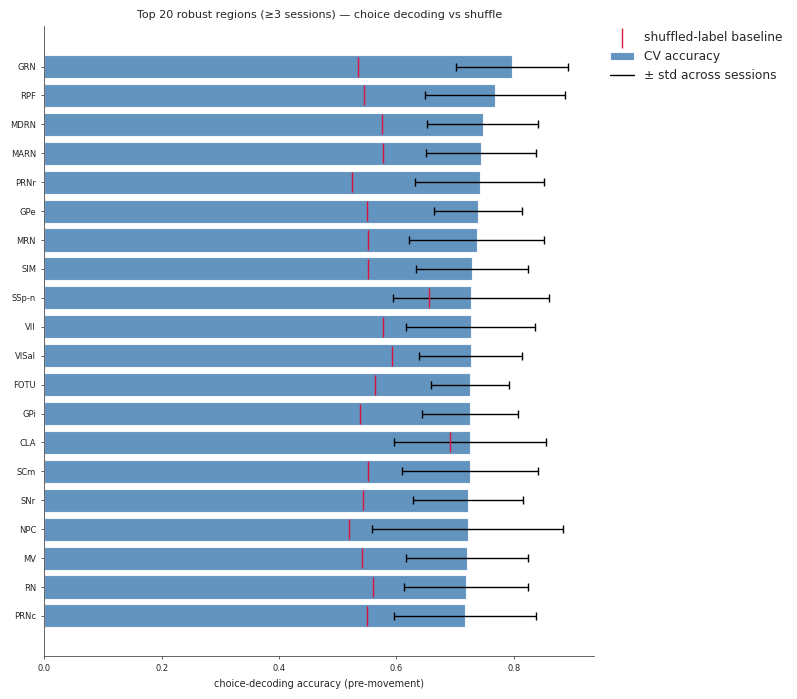

In [18]:
# Plot the top regions by mean pre-movement choice-decoding accuracy vs shuffle baseline.
# Uses `robust_region_df` (n_sessions >= MIN_SESSIONS) so single-session artifacts are
# excluded and every bar carries a real cross-session error bar.
TOP_N = 20
plot_df = robust_region_df.head(TOP_N).iloc[::-1]  # reverse so best is at the top of a horizontal bar

fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(plot_df))))
ypos = np.arange(len(plot_df))
ax.barh(ypos, plot_df['mean_cv_acc'], xerr=plot_df['std_cv_acc'].fillna(0),
        color='steelblue', alpha=0.85, ecolor='black', capsize=3, label='CV accuracy')
ax.scatter(plot_df['mean_shuffle'], ypos, color='crimson', zorder=3,
           marker='|', s=200, label='shuffled-label baseline')
# Proxy handle so the black whiskers get their own legend entry.
err_handle = plt.Line2D([0], [0], color='black', lw=1, label='± std across sessions')
ax.set_yticks(ypos)
ax.set_yticklabels(plot_df['region'])
ax.set_xlabel('choice-decoding accuracy (pre-movement)')
ax.set_title(f'Top {TOP_N} robust regions (≥{MIN_SESSIONS} sessions) — choice decoding vs shuffle')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [err_handle], loc='upper left',
          bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0, frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


In [19]:
# Map region acronyms to full Allen Mouse Brain Atlas names
# Adds a `region_name` column so the ranked table is self-documenting.
# Applied to `robust_region_df` (n_sessions >= MIN_SESSIONS) to stay consistent
# with the plotted ranking.
from iblatlas.regions import BrainRegions

br = BrainRegions()

# Canonical acronym -> full Allen region name.
# NOTE: br.acronym is not unique (atlas is lateralized: left/right share an acronym),
# so dict(zip(...)) keeps one canonical name per acronym, which is what we want here.
acronym_to_name = dict(zip(br.acronym, br.name))

# Keep the original acronym as a fallback if a label is not found in the ontology.
robust_region_df["region_name"] = (
    robust_region_df["region"].map(acronym_to_name).fillna(robust_region_df["region"])
)

# Show the ranked robust regions with their full names (name next to the acronym).
cols = ["region", "region_name", "n_sessions", "mean_cv_acc", "std_cv_acc", "mean_shuffle", "total_units", "above_chance"]
robust_region_df[cols].head(25)


,region,region_name,n_sessions,mean_cv_acc,std_cv_acc,mean_shuffle,total_units,above_chance
0,GRN,Gigantocellular reticular nucleus (left),14,0.796979,0.095260,0.535012,555,0.261967
1,RPF,Retroparafascicular nucleus (left),4,0.767286,0.119308,0.544397,42,0.222890
2,MDRN,Medullary reticular nucleus (left),7,0.746680,0.095223,0.575549,177,0.171132
3,MARN,Magnocellular reticular nucleus (left),3,0.743699,0.093695,0.577252,80,0.166447
4,PRNr,Pontine reticular nucleus (left),20,0.741879,0.109810,0.524600,761,0.217279
5,GPe,Globus pallidus external segment (left),11,0.739325,0.075433,0.549179,319,0.190146
6,MRN,Midbrain reticular nucleus (left),110,0.736490,0.115387,0.550816,2632,0.185674
7,SIM,Simple lobule (left),19,0.728975,0.095110,0.551696,888,0.177279
8,SSp-n,Primary somatosensory area nose (left),3,0.727052,0.133451,0.655251,64,0.071801
9,VII,Facial motor nucleus (left),6,0.726781,0.109848,0.576294,63,0.150487


## Bonus — Decoding the block prior from pre-stimulus population activity

The IBL task runs in *blocks*: for a run of trials the stimulus is more likely on
one side, encoded by `trials.probabilityLeft` (0.8 = left-biased block,
0.2 = right-biased block, 0.5 = unbiased block at the start of a session). This
prior is an **internal, contextual belief** the animal carries across trials — it
is not evoked by any single stimulus or movement.

**Question.** Can we read the current block out of neural population activity
*before the stimulus even appears*?

**Design (mirrors Q3).**
- **Data / window.** We use the `stimOn`-aligned PSTHs and average firing rates in
  the **pre-stimulus** window (`t < 0`). Reading the prior *before* stimulus onset
  keeps the decode free of any stimulus-evoked signal — it can only reflect the
  standing prior.
- **Labels.** Binary **0.2 vs 0.8** (right-biased vs left-biased block). We drop the
  unbiased `0.5` trials so the problem matches Q3's binary structure and chance is 0.5.
- **Pipeline.** Same per-(region, session) `StandardScaler` + `LogisticRegression`
  under `StratifiedKFold` CV, with a shuffled-label baseline, the same
  `MIN_UNITS` / `MIN_TRIALS` gates, and the same `MIN_SESSIONS` reporting filter.
- **Cache.** Shares the same git-tracked `./decode_cache/` folder as Q3, with its
  own files (`block_decode_sessions.parquet` + `block_decode_regions.parquet`).


In [20]:
# Load the stimulus-onset-aligned dataset for the block-prior decode.
download_data('stimOn')
meta_so = load_metadata('stimOn')

# Pre-stimulus feature window: activity BEFORE stimulus onset (t < 0).
# The block prior is a standing belief, so pre-stimulus firing carries it without
# any stimulus-evoked confound.
PRE_STIM = (-0.4, 0.0)
time_mask_so = np.bitwise_and(meta_so.times < PRE_STIM[1], meta_so.times >= PRE_STIM[0])

print('stimOn metadata loaded')
print('n clusters:', len(meta_so.clusters))
print('time range:', meta_so.times[0], 'to', meta_so.times[-1], 's | dt:', meta_so.dt)
print(f'feature window {PRE_STIM} → {int(time_mask_so.sum())} bins')

# Sanity check: how the block prior is distributed across trials.
print('\nprobabilityLeft value counts:')
print(meta_so.trials['probabilityLeft'].value_counts(dropna=False))


stimOn metadata loaded
n clusters: 75708
time range: -0.495 to 0.995 s | dt: 0.01
feature window (-0.4, 0.0) → 40 bins

probabilityLeft value counts:
probabilityLeft
0.8    86670
0.2    82170
0.5    27663
Name: count, dtype: int64


In [21]:
# Decode the block prior for a region across all sessions it appears in.
# Reuses decode_region_session() (generic binary CV + shuffle baseline) and the
# same MIN_UNITS / MIN_TRIALS gates as Q3. Labels are the biased blocks only:
# probabilityLeft == 0.8 (left-biased) vs 0.2 (right-biased); 0.5 is dropped.
BLOCK_LEFT = 0.8   # left-biased block
BLOCK_RIGHT = 0.2  # right-biased block

def decode_block_for_region(reg, meta, time_mask):
    """Decode the block prior per session for `reg`; return a per-session results list.

    Each session is decoded independently. A session-region is skipped unless it
    clears MIN_UNITS and MIN_TRIALS and has both biased-block classes present.
    """
    all_psth, all_clust, all_trials = get_psth_for_region(reg, meta)
    sessions = []
    for psth, clust, trials in zip(all_psth, all_clust, all_trials):
        # psth: (trials, units, nbins). Pre-stimulus mean firing rate per unit.
        X = psth[:, :, time_mask].mean(axis=2)
        prob = trials['probabilityLeft'].values
        # Keep only the two biased blocks; drop the unbiased 0.5 block.
        keep = np.isin(prob, [BLOCK_LEFT, BLOCK_RIGHT])
        X = X[keep]
        # Binary label: +1 = left-biased (0.8), -1 = right-biased (0.2).
        y = np.where(prob[keep] == BLOCK_LEFT, 1, -1)
        # Inclusion gates.
        n_trials, n_units = X.shape
        if n_units < MIN_UNITS or n_trials < MIN_TRIALS:
            continue
        if np.unique(y).size < 2:
            continue
        # Need each class to have at least N_SPLITS members for StratifiedKFold.
        _, counts = np.unique(y, return_counts=True)
        if counts.min() < N_SPLITS:
            continue
        cv_acc, shuf_mean, shuf_std = decode_region_session(X, y)
        sessions.append({
            'region': reg,
            'n_units': int(n_units),
            'n_trials': int(n_trials),
            'cv_acc': cv_acc,
            'shuffle_acc': shuf_mean,
            'shuffle_std': shuf_std,
        })
    return sessions


In [22]:
# Cache infrastructure for the block-prior sweep.
# Reuses the SAME shared cache folder as Q3 (CACHE_DIR, defined in the Q3 cache
# infra cell) — only the parquet basenames differ, so both sweeps' files live
# side by side in one committed ./decode_cache/ folder.
# Reuses aggregate_region_df() from the Q3 cells.

BLOCK_SESSION_CACHE = os.path.join(CACHE_DIR, 'block_decode_sessions.parquet')
BLOCK_REGION_CACHE = os.path.join(CACHE_DIR, 'block_decode_regions.parquet')


def compute_block_decoding():
    """Run the block-prior decode across every region (the expensive step)."""
    regions = [r for r in meta_so.clusters['acronym'].unique() if r not in ('root', 'void')]
    print(f'decoding block prior for {len(regions)} regions...')

    session_records = []
    for reg in tqdm.tqdm(regions):
        session_records.extend(decode_block_for_region(reg, meta_so, time_mask_so))

    session_df = pd.DataFrame(session_records)
    region_df = aggregate_region_df(session_df)  # reused from the Q3 cache cell
    return session_df, region_df


def load_or_compute_block_decoding():
    """Load the committed block cache if present; else (Colab only) compute + save.

    Returns (block_session_df, block_region_df).
    """
    cache_present = os.path.exists(BLOCK_SESSION_CACHE) and os.path.exists(BLOCK_REGION_CACHE)

    if cache_present and not FORCE_RERUN:
        session_df = pd.read_parquet(BLOCK_SESSION_CACHE)
        region_df = pd.read_parquet(BLOCK_REGION_CACHE)
        print(f'loaded committed block cache from {CACHE_DIR}')
        print(f'  session_df: {session_df.shape[0]} session-region rows')
        print(f'  region_df:  {region_df.shape[0]} regions')
        return session_df, region_df

    if IN_COLAB:
        session_df, region_df = compute_block_decoding()
        session_df.to_parquet(BLOCK_SESSION_CACHE, index=False)
        region_df.to_parquet(BLOCK_REGION_CACHE, index=False)
        print(f'saved block cache to {CACHE_DIR}')
        print('Next: download these two files into your local repo and commit them:')
        print(f'  {BLOCK_SESSION_CACHE}')
        print(f'  {BLOCK_REGION_CACHE}')
        print('  git add decode_cache/*.parquet && git commit -m "add block decode cache"')
        return session_df, region_df

    raise FileNotFoundError(
        'No cache found in ./decode_cache/ and local runs do not recompute.\n'
        'The cache is normally committed to the repo. Either:\n'
        '  - pull/checkout the branch that contains decode_cache/*.parquet, or\n'
        '  - run this notebook in Colab with FORCE_RERUN = True to generate it,\n'
        '    then download the two parquet files into ./decode_cache/ and commit them:\n'
        '      - block_decode_sessions.parquet\n'
        '      - block_decode_regions.parquet'
    )


In [23]:
# Execute the block-prior caching workflow: Colab computes+saves, local loads.
block_session_df, block_region_df = load_or_compute_block_decoding()

# Same reporting-only robustness filter as Q3: report regions seen in >= MIN_SESSIONS
# sessions so single-session artifacts do not headline the ranking. The full
# block_region_df / block_session_df stay intact.
block_robust_region_df = (
    block_region_df[block_region_df["n_sessions"] >= MIN_SESSIONS]
    .reset_index(drop=True)
)

# Headline table = trustworthy multi-session regions, ranked by block-decoding accuracy.
block_robust_region_df.head(25)


decoding block prior for 266 regions...


100%|██████████| 266/266 [34:51<00:00,  7.86s/it]

saved block cache to /content/cn-project/decode_cache
Next: download these two files into your local repo and commit them:
  /content/cn-project/decode_cache/block_decode_sessions.parquet
  /content/cn-project/decode_cache/block_decode_regions.parquet
  git add decode_cache/*.parquet && git commit -m "add block decode cache"


,region,n_sessions,mean_cv_acc,std_cv_acc,mean_shuffle,total_units,above_chance
0,MARN,3,0.713821,0.057344,0.553304,80,0.160517
1,VCO,4,0.701365,0.038315,0.523159,138,0.178205
2,SPVO,8,0.682582,0.051278,0.595095,129,0.087487
3,PRNc,9,0.677887,0.047865,0.546837,276,0.131050
4,PRNr,20,0.674286,0.065405,0.532007,761,0.142280
5,SUV,13,0.673214,0.060149,0.543553,277,0.129661
6,GRN,14,0.670241,0.056781,0.525886,555,0.144356
7,SIM,19,0.664807,0.075578,0.520323,888,0.144485
8,DN,6,0.664404,0.066267,0.516026,191,0.148378
9,DCO,12,0.663235,0.080836,0.515795,308,0.147441


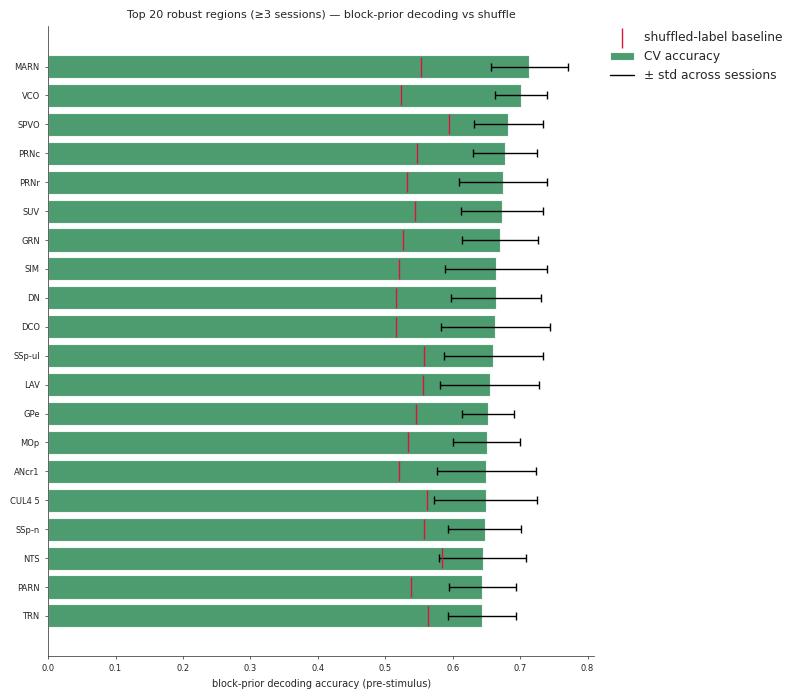

In [24]:
# Plot the top regions by mean pre-stimulus block-prior decoding accuracy vs shuffle.
# Uses block_robust_region_df (n_sessions >= MIN_SESSIONS) so every bar has a real
# cross-session error bar.
TOP_N = 20
bplot_df = block_robust_region_df.head(TOP_N).iloc[::-1]  # best at the top

fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(bplot_df))))
ypos = np.arange(len(bplot_df))
ax.barh(ypos, bplot_df['mean_cv_acc'], xerr=bplot_df['std_cv_acc'].fillna(0),
        color='seagreen', alpha=0.85, ecolor='black', capsize=3, label='CV accuracy')
ax.scatter(bplot_df['mean_shuffle'], ypos, color='crimson', zorder=3,
           marker='|', s=200, label='shuffled-label baseline')
# Proxy handle so the black whiskers get their own legend entry.
err_handle = plt.Line2D([0], [0], color='black', lw=1, label='± std across sessions')
ax.set_yticks(ypos)
ax.set_yticklabels(bplot_df['region'])
ax.set_xlabel('block-prior decoding accuracy (pre-stimulus)')
ax.set_title(f'Top {TOP_N} robust regions (≥{MIN_SESSIONS} sessions) — block-prior decoding vs shuffle')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [err_handle], loc='upper left',
          bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0, frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


In [25]:
# Map region acronyms to full Allen Mouse Brain Atlas names for the block-prior table.
# Reuses the acronym_to_name lookup built in the Q3 naming cell.
block_robust_region_df["region_name"] = (
    block_robust_region_df["region"].map(acronym_to_name).fillna(block_robust_region_df["region"])
)

cols = ["region", "region_name", "n_sessions", "mean_cv_acc", "std_cv_acc", "mean_shuffle", "total_units", "above_chance"]
block_robust_region_df[cols].head(25)


,region,region_name,n_sessions,mean_cv_acc,std_cv_acc,mean_shuffle,total_units,above_chance
0,MARN,Magnocellular reticular nucleus (left),3,0.713821,0.057344,0.553304,80,0.160517
1,VCO,Ventral cochlear nucleus (left),4,0.701365,0.038315,0.523159,138,0.178205
2,SPVO,Spinal nucleus of the trigeminal oral part (left),8,0.682582,0.051278,0.595095,129,0.087487
3,PRNc,Pontine reticular nucleus caudal part (left),9,0.677887,0.047865,0.546837,276,0.131050
4,PRNr,Pontine reticular nucleus (left),20,0.674286,0.065405,0.532007,761,0.142280
5,SUV,Superior vestibular nucleus (left),13,0.673214,0.060149,0.543553,277,0.129661
6,GRN,Gigantocellular reticular nucleus (left),14,0.670241,0.056781,0.525886,555,0.144356
7,SIM,Simple lobule (left),19,0.664807,0.075578,0.520323,888,0.144485
8,DN,Dentate nucleus (left),6,0.664404,0.066267,0.516026,191,0.148378
9,DCO,Dorsal cochlear nucleus (left),12,0.663235,0.080836,0.515795,308,0.147441
